In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

In [19]:
hough = pd.read_csv("/Users/jdreiling/Desktop/puck/puck/results/houghMultiTest/3/hough_results_cleaned.csv")
pp = pd.read_csv("/Users/jdreiling/Desktop/puck/puck/results/pipeline_results/ppMultiTest/3/paperPrograms_results.csv")

In [21]:
hough.head()

,Unnamed: 0,palette,loc,height,set,blobCount,closeEnough,count4,closeCount4,time,points,path
0,0,custom,davids,high,A,4,True,True,True,231719125,"[0.7071067811865476, 0.7071067811865476, 0.707...",custom_davids_high_A_0.jpg
1,1,custom,davids,high,A,5,True,False,False,224280000,"[0.7071067811865476, 0.7071067811865476, 1.581...",custom_davids_high_A_1.jpg
2,2,custom,davids,high,A,4,True,True,True,214637708,"[0.7071067811865476, 0.7071067811865476, 1.581...",custom_davids_high_A_2.jpg
3,3,custom,davids,high,A,4,True,True,True,219690500,"[0.7071067811865476, 1.5811388300841898, 1.581...",custom_davids_high_A_3.jpg
4,4,custom,davids,high,A,4,True,True,True,218660583,"[1.5811388300841898, 1.5811388300841898, 1.581...",custom_davids_high_A_4.jpg


In [22]:
pp.head()

,Unnamed: 0,palette,loc,height,set,blobCount,closeEnough,count4,closeCount4,time,points,path
0,0,custom,davids,high,A,4,True,True,True,246198542,"[0.0, 1.0, 1.0, 1.0]",custom_davids_high_A_0.jpg
1,1,custom,davids,high,A,5,True,False,False,249145292,"[1.0, 1.0, 1.0, 2.23606797749979, 906.52082160...",custom_davids_high_A_1.jpg
2,2,custom,davids,high,A,4,True,True,True,243674750,"[0.0, 1.0, 1.0, 1.4142135623730951]",custom_davids_high_A_2.jpg
3,3,custom,davids,high,A,4,True,True,True,255843042,"[1.0, 1.0, 2.0, 2.23606797749979]",custom_davids_high_A_3.jpg
4,4,custom,davids,high,A,4,True,True,True,238556000,"[1.0, 1.0, 1.4142135623730951, 2.0]",custom_davids_high_A_4.jpg


In [16]:
def cleaner(path):
    print(path)
    df = pd.read_csv(path)
    print(df)
    df.columns =["name","blobCount", "closeEnough", "closeCount4", "time", "points"]
    df[['images','palette', 'loc', 'height', 'set', "path"]] = df.name.str.split("/",expand=True)
    df = df.drop(["images", "name",], axis = 1)
    df["count4"] =(df["blobCount"] == 4)
    df_reordered = df.loc[:, ["palette", "loc", "height", "set", 'blobCount', 'closeEnough', 'count4', 'closeCount4', "time","points", "path"]] 
    df_reordered.to_csv(path[:-4] + "_cleaned.csv")


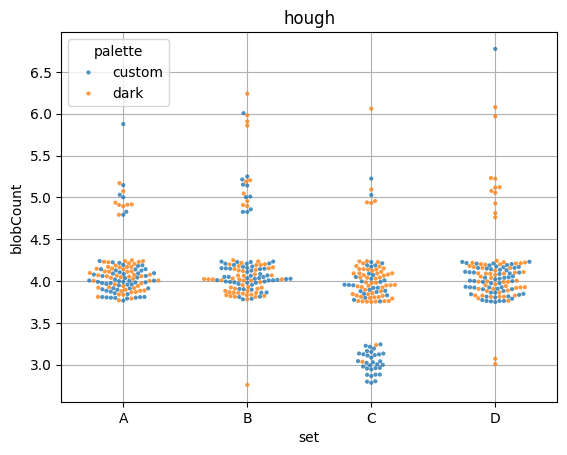

In [28]:
random.seed(2026)
adjust= [random.uniform(-.25,.25) for _ in range(480)]
hough["blobCount"] = hough["blobCount"] + adjust
sns.swarmplot(data=hough, x="set", y="blobCount", hue= "palette", alpha = .8, size = 3)
plt.title("hough")
plt.grid() 
plt.show()

['0.7071067811865476', ' 0.7071067811865476', ' 0.7071067811865476', ' 1.5811388300841898', '0.7071067811865476', ' 0.7071067811865476', ' 1.5811388300841898', ' 1.5811388300841898', '0.7071067811865476', ' 0.7071067811865476', ' 1.5811388300841898', ' 1.5811388300841898', '0.7071067811865476', ' 1.5811388300841898', ' 1.5811388300841898', ' 1.5811388300841898', '1.5811388300841898', ' 1.5811388300841898', ' 1.5811388300841898', ' 1.5811388300841898', '0.7071067811865476', ' 0.7071067811865476', ' 2.1213203435596424', ' 2.1213203435596424', '0.7071067811865476', ' 0.7071067811865476', ' 0.7071067811865476', ' 1.5811388300841898', '1.5811388300841898', ' 1.5811388300841898', ' 1.5811388300841898', ' 1.5811388300841898', '0.7071067811865476', ' 1.5811388300841898', ' 1.5811388300841898', ' 1.5811388300841898', '0.7071067811865476', ' 1.5811388300841898', ' 1.5811388300841898', ' 2.9154759474226504', '0.7071067811865476', ' 1.5811388300841898', ' 2.1213203435596424', '0.7071067811865476',

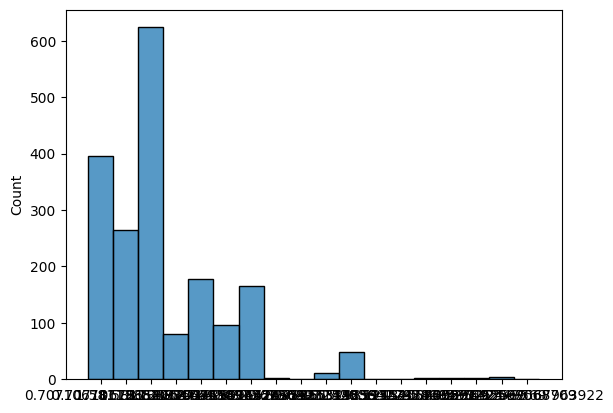

In [ ]:
possible_dist = []
for x in hough["points"]:
    x = x.lstrip("[")
    x= x.rstrip("]")
    dists = x.split(",")
    first_four = dists[0:4]
    for d in first_four:
        possible_dist.append(d)

print(possible_dist)
sns.histplot(data=possible_dist)
plt.show()

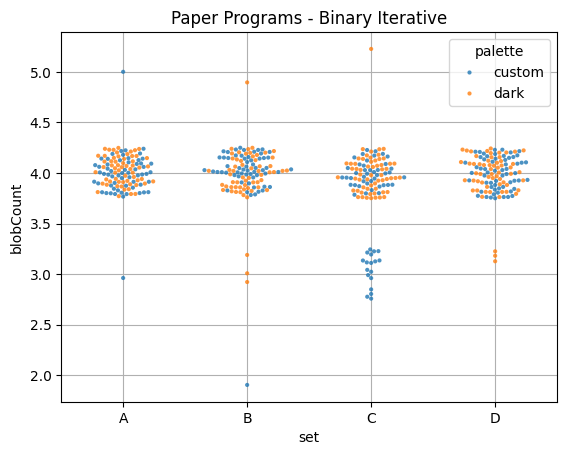

In [29]:
random.seed(2026)
adjust= [random.uniform(-.25,.25) for _ in range(480)]
pp["blobCount"] = pp["blobCount"] + adjust
sns.swarmplot(data=pp, x="set", y="blobCount", hue= "palette", alpha = .8, size = 3)
plt.title("Paper Programs - Binary Iterative")
plt.grid() 
plt.show()

In [8]:
# HOUGH MASS TESTING RESULTS
hough_normal_path = "/Users/jdreiling/Desktop/puck/puck/results/houghCircle_results.csv"
hough_alt_path = "/Users/jdreiling/Desktop/puck/puck/results/houghCircleAlt_results.csv"

In [9]:
hough_normal = pd.read_csv(hough_normal_path)
hough_alt= pd.read_csv(hough_alt_path)

In [10]:
hough_normal.head()

,Unnamed: 0,0,1,2,3
0,"(np.float64(1.0), 280, 130, 30, 15)",houghCircle,0.820833,43819581.13,33392671.0
1,"(np.float64(1.5), 280, 130, 30, 15)",houghCircle,0.820833,46281812.72,33905763.5
2,"(np.float64(1.0), 270, 130, 30, 15)",houghCircle,0.818750,47107569.90,34478858.0
3,"(np.float64(1.5), 270, 130, 30, 15)",houghCircle,0.818750,45041269.23,34826285.5
4,"(np.float64(1.0), 240, 130, 30, 15)",houghCircle,0.816667,42225158.50,33187454.5


In [6]:
hough_alt.head()

,Unnamed: 0,0,1,2,3
0,"(np.float64(1.5), 170, 310, np.float64(0.90000...",houghCircleAlt,0.939583,28041396.61,28578495.5
1,"(np.float64(1.5), 190, 310, np.float64(0.90000...",houghCircleAlt,0.939583,28225471.35,28777087.0
2,"(np.float64(1.5), 200, 310, np.float64(0.90000...",houghCircleAlt,0.939583,28087322.11,28647504.0
3,"(np.float64(1.5), 170, 300, np.float64(0.90000...",houghCircleAlt,0.937500,27764186.99,28378609.0
4,"(np.float64(1.5), 170, 320, np.float64(0.90000...",houghCircleAlt,0.937500,27487055.39,27822060.5


In [11]:
def pipeline_splitter(big_df):
    big_df.columns =["pipeline","choice","accuracy", "averageTime", "medianTime"]
    big_df[['dp','minDist', 'param1', 'param2', 'minRad']] = big_df.pipeline.str.split(",",expand=True)
    

In [12]:
pipeline_splitter(hough_alt)

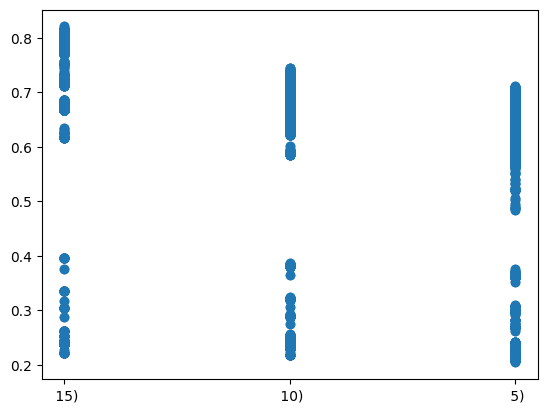

In [19]:
plt.scatter(x=hough_normal["minRad"], y = hough_normal["accuracy"])

In [15]:
hough_alt["pipeline"][0:10]

0    (np.float64(1.5), 170, 310, np.float64(0.90000...
1    (np.float64(1.5), 190, 310, np.float64(0.90000...
2    (np.float64(1.5), 200, 310, np.float64(0.90000...
3    (np.float64(1.5), 170, 300, np.float64(0.90000...
4    (np.float64(1.5), 170, 320, np.float64(0.90000...
5    (np.float64(1.5), 170, 330, np.float64(0.90000...
6    (np.float64(1.5), 170, 340, np.float64(0.90000...
7    (np.float64(1.5), 180, 310, np.float64(0.90000...
8    (np.float64(1.5), 190, 300, np.float64(0.90000...
9    (np.float64(1.5), 190, 320, np.float64(0.90000...
Name: pipeline, dtype: object

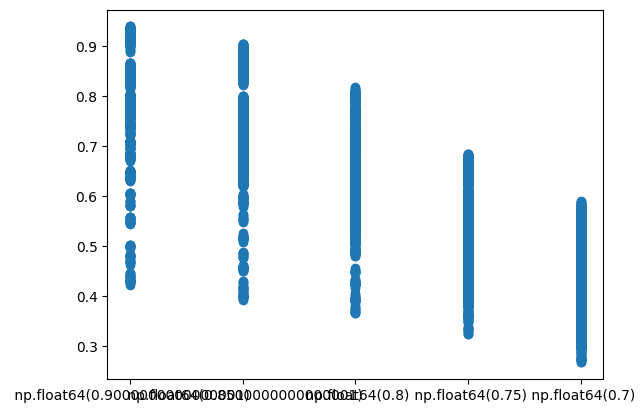

In [24]:
plt.scatter(x=hough_alt["param2"], y = hough_alt["accuracy"])